<a href="https://colab.research.google.com/github/DeepanshuSharma1607/ipl-winner-pedictor/blob/main/ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2475]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2476]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "IPL_ball_by_ball_updated.csv"

# Load the latest version
df_23= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.


In [2477]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "deliveries_updated_ipl_upto_2025.csv"

# Load the latest version
df_ = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.


In [2478]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path1 = "ipl_2024_deliveries.csv"
file_path2 = "ipl_2025_deliveries.csv"
file_path3 = "ipl_2026_deliveries.csv"
# Load the latest version
df_24= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path1,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df_25= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path2,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df_26= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path3,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.
Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.
Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.


In [2479]:
df_['season']=pd.to_datetime(df_['date']).dt.year

In [2480]:
dv=[df_,df_23,df_24,df_25,df_26]
mapping = {
    'start_date':'date'
}
df_23.rename(columns=mapping, inplace=True)

In [2481]:
for df in dv:
  df['date']=pd.to_datetime(df['date'])

In [2482]:
team_mapping = {
    # Current name
    'Delhi Capitals': 'DC',
    # Old name → same short code
    'Delhi Daredevils': 'DC',

    'Punjab Kings': 'PBKS',
    'Kings XI Punjab': 'PBKS',

    'Royal Challengers Bangalore': 'RCB',
    'Royal Challengers Bengaluru': 'RCB',

    # Never changed
    'Kolkata Knight Riders': 'KKR',
    'Chennai Super Kings': 'CSK',
    'Rajasthan Royals': 'RR',
    'Mumbai Indians': 'MI',
    'Sunrisers Hyderabad': 'SRH',
    'Lucknow Super Giants': 'LSG',
    'Gujarat Titans': 'GT',

    # Dissolved teams
    'Deccan Chargers': 'DC_OLD',
    'Kochi Tuskers Kerala': 'KTK',
    'Pune Warriors': 'PWI',
    'Rising Pune Supergiants': 'RPS',
    'Rising Pune Supergiant': 'RPS',
    'Gujarat Lions': 'GL',
}


# Apply to both team columns
df_['batting_team'] = df_['batting_team'].replace(team_mapping)
df_['bowling_team'] = df_['bowling_team'].replace(team_mapping)

df_23['batting_team'] = df_23['batting_team'].replace(team_mapping)
df_23['bowling_team'] = df_23['bowling_team'].replace(team_mapping)


In [2483]:
venue_sources = [df_23, df_24, df_25, df_26]

venue_lookup = pd.concat([
    df[['date', 'batting_team', 'bowling_team', 'venue']]
    for df in venue_sources
]).drop_duplicates(subset=['date', 'batting_team', 'bowling_team'])

In [2484]:
if 'venue' in df_.columns:
    df_ = df_.drop(columns=['venue'])

df_ = df_.merge(
    venue_lookup,
    on=['date', 'batting_team', 'bowling_team'],
    how='left'
)

In [2485]:
df_.head(2)

,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,...,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date,season,venue
0,335982,1,0.1,0,1,KKR,RCB,SC Ganguly,BB McCullum,P Kumar,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2008-04-18,2008,M Chinnaswamy Stadium
1,335982,1,0.2,0,2,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18,2008,M Chinnaswamy Stadium


In [2486]:
df_=df_.drop(columns=["over","ball"])

In [2487]:
df_=df_.drop(columns=["date","Penalty","non_striker"])

In [2488]:
df_26=df_26.drop(columns=["date",'match_no',"phase","fielder"])

In [2489]:
print(df_.shape)
print(df_26.shape)

(278205, 17)
(1382, 17)


In [2490]:
df_.columns

Index(['matchId', 'inning', 'over_ball', 'batting_team', 'bowling_team',
       'batsman', 'bowler', 'batsman_runs', 'extras', 'isWide', 'isNoBall',
       'Byes', 'LegByes', 'dismissal_kind', 'player_dismissed', 'season',
       'venue'],
      dtype='object')

In [2491]:
mapping = {
    "innings":"inning",
}
df_26.rename(columns=mapping, inplace=True)
df_26.columns

Index(['match_id', 'season', 'venue', 'batting_team', 'bowling_team', 'inning',
       'over', 'striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'legbyes',
       'byes', 'noballs', 'wicket_type', 'player_dismissed'],
      dtype='object')

In [2492]:
#Rename columns
mapping = {
    'matchId':'match_id',
    'over_ball':'over',
    'batsman':'striker',
    'isWide':'wide',
    'isNoBall':'noballs',
    "batsman_runs":"runs_of_bat",
    "dismissal_kind":"wicket_type",
    "LegByes":"legbyes",
    "Byes":"byes"

}
df_.rename(columns=mapping, inplace=True)

In [2493]:
df_['venue'] = (df_['venue']
             .str.split(',').str[0]
             .str.strip()
             .str.lower()
             .str.replace(' ', '_'))
df_26['venue'] = (df_26['venue']
             .str.split(',').str[0]
             .str.strip()
             .str.lower()
             .str.replace(' ', '_'))


In [2494]:
df = pd.concat([df_, df_26])
print(df.shape)
display(df.head())

(279587, 17)


,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,noballs,byes,legbyes,wicket_type,player_dismissed,season,venue
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,2008,m_chinnaswamy_stadium
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium


In [2495]:
df.isnull().sum()

,0
match_id,0
inning,0
over,0
batting_team,0
bowling_team,0
striker,0
bowler,0
runs_of_bat,0
extras,0
wide,269125


In [2496]:
df['bowling_team'].nunique()

15

In [2497]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue'],
      dtype='object')

In [2498]:
print(df[['runs_of_bat', 'extras', 'wide',
       'noballs', 'byes', 'legbyes', 'wicket_type', 'player_dismissed']])

      runs_of_bat  extras  wide  noballs  byes  legbyes wicket_type  \
0               0       1   NaN      NaN   NaN      1.0         NaN   
1               0       0   NaN      NaN   NaN      NaN         NaN   
2               0       1   1.0      NaN   NaN      NaN         NaN   
3               0       0   NaN      NaN   NaN      NaN         NaN   
4               0       0   NaN      NaN   NaN      NaN         NaN   
...           ...     ...   ...      ...   ...      ...         ...   
1377            1       0   0.0      0.0   0.0      0.0         NaN   
1378            0       0   0.0      0.0   0.0      0.0         NaN   
1379            1       0   0.0      0.0   0.0      0.0         NaN   
1380            0       0   0.0      0.0   0.0      0.0      caught   
1381            0       0   0.0      0.0   0.0      0.0      bowled   

         player_dismissed  
0                     NaN  
1                     NaN  
2                     NaN  
3                     NaN  
4      

In [2499]:
cols_to_fix = ['runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes']
df[cols_to_fix] = df[cols_to_fix].fillna(0)

df['curr_ball_runs'] = df['runs_of_bat'] + df['extras']
total_score = df.groupby(['match_id', 'inning', 'batting_team'])['curr_ball_runs'].cumsum().reset_index()


In [2500]:
df['team_runs'] = df.groupby(['match_id','batting_team'])['curr_ball_runs'].cumsum()
df['team_runs'] = df.groupby(['match_id','batting_team'])['team_runs'].shift(1).fillna(0)

In [2501]:
df['first_innings_runs'] = np.where(df['inning'] == 1, df['team_runs'], 0)

df['second_innings_runs'] = np.where(df['inning'] == 2, df['team_runs'], 0)

In [2502]:
df

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,...,byes,legbyes,wicket_type,player_dismissed,season,venue,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,0.0,...,0.0,1.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,0.0,0.0,0.0
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,1.0,1.0,0.0
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,1.0,1.0,0.0
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,202606,2,15.2,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,1,0,0.0,...,0.0,0.0,NaN,NaN,2026,eden_gardens,1,158.0,0.0,158.0
1378,202606,2,15.3,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,0,0,0.0,...,0.0,0.0,NaN,NaN,2026,eden_gardens,0,159.0,0.0,159.0
1379,202606,2,15.4,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,1,0,0.0,...,0.0,0.0,NaN,NaN,2026,eden_gardens,1,159.0,0.0,159.0
1380,202606,2,15.5,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,0,0,0.0,...,0.0,0.0,caught,Kartik Tyagi,2026,eden_gardens,0,160.0,0.0,160.0


In [2503]:
df['is_wicket']=df['player_dismissed'].notna().astype(int)

In [2504]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket'],
      dtype='object')

In [2505]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279587 entries, 0 to 1381
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   match_id             279587 non-null  int64  
 1   inning               279587 non-null  int64  
 2   over                 279587 non-null  float64
 3   batting_team         279587 non-null  object 
 4   bowling_team         279587 non-null  object 
 5   striker              279587 non-null  object 
 6   bowler               279587 non-null  object 
 7   runs_of_bat          279587 non-null  int64  
 8   extras               279587 non-null  int64  
 9   wide                 279587 non-null  float64
 10  noballs              279587 non-null  float64
 11  byes                 279587 non-null  float64
 12  legbyes              279587 non-null  float64
 13  wicket_type          13904 non-null   object 
 14  player_dismissed     13901 non-null   object 
 15  season               279

In [2506]:
df

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,...,legbyes,wicket_type,player_dismissed,season,venue,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs,is_wicket
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,0.0,...,1.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,0.0,0.0,0.0,0
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,1.0,1.0,0.0,0
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,1.0,1.0,0.0,0
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0,0
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,202606,2,15.2,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,1,0,0.0,...,0.0,NaN,NaN,2026,eden_gardens,1,158.0,0.0,158.0,0
1378,202606,2,15.3,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,0,0,0.0,...,0.0,NaN,NaN,2026,eden_gardens,0,159.0,0.0,159.0,0
1379,202606,2,15.4,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,1,0,0.0,...,0.0,NaN,NaN,2026,eden_gardens,1,159.0,0.0,159.0,0
1380,202606,2,15.5,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,0,0,0.0,...,0.0,caught,Kartik Tyagi,2026,eden_gardens,0,160.0,0.0,160.0,1


In [2507]:
# final_scores = df[df['inning'] == 1].groupby('match_id')['team_runs'].max()
# df = df.merge(final_scores.rename('target'), on='match_id')
# df['target'] = np.where(df['inning'] == 2, df['target'] + 1, 0)
actual_totals = (df[df['inning'] == 1]
                 .groupby('match_id')['curr_ball_runs']
                 .sum()
                 .rename('target'))
df = df.merge(actual_totals, on='match_id')
df['target'] = np.where(df['inning'] == 2, df['target'] + 1, 0)

In [2508]:
df['over_'] = df['over'].astype(str).str.split('.').str[0].astype(int)
df['ball_in_over'] = (df['over'].astype(str)
                      .str.split('.')
                      .str[1]
                      .fillna(0)
                      .astype(int))

In [2509]:
df['ball_in_over'] = df['ball_in_over'].clip(upper=6)
df['balls_bowled'] = df['over_'] * 6 + df['ball_in_over']

In [2510]:
df['runs_to_win'] = np.where(
    df['inning'] == 2,
    df['target'] - df['team_runs'],
    0
)

In [2511]:
balls_remaining = (120 - df['balls_bowled']).clip(lower=0)


In [2512]:
df['curr_run_rate'] = np.where(
    df['balls_bowled'] == 0, 0,
    (df['team_runs'] * 6) / df['balls_bowled']
)

In [2513]:
df['req_run_rate'] = np.where(
    balls_remaining == 0,
    np.inf,
    (df['runs_to_win'] * 6) / balls_remaining
)
df['req_run_rate'] = df['req_run_rate'].clip(0, 36)


In [2514]:
df['req_run_rate'] = df['req_run_rate'].replace(np.inf, 100)

In [2515]:
df['crr_rrr_ratio'] = df['curr_run_rate'] / df['req_run_rate'].replace(0, np.inf)

df['crr_rrr_ratio'] = df['crr_rrr_ratio'].clip(0, 10)

df.loc[df['inning'] == 1,
       ['target', 'runs_to_win', 'req_run_rate', 'crr_rrr_ratio']] = 0

In [2516]:
df['balls_remaining'] = (20 * 6) - df['balls_bowled'].clip(lower=0)

In [2517]:
df['total_wickets'] = df.groupby(['match_id','inning'])['is_wicket'].cumsum()
df['total_wickets'] = df.groupby(['match_id','inning'])['total_wickets'].shift(1).fillna(0)
df['wickets_remaining'] = 10 - df['total_wickets']

In [2518]:
df = df.sort_values(['match_id', 'inning', 'balls_bowled'])
df['recent_wickets'] = (
    df.groupby(['match_id', 'inning'])['is_wicket']
    .transform(lambda x: x.shift(1).rolling(18, min_periods=1).sum())
    .fillna(0)
)

df['recent_runs'] = (
    df.groupby(['match_id', 'inning'])['curr_ball_runs']
    .transform(lambda x: x.shift(1).rolling(18, min_periods=1).sum())
    .fillna(0)
)

In [2519]:
df

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,...,balls_bowled,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,total_wickets,wickets_remaining,recent_wickets,recent_runs
278205,202601,1,0.1,SRH,RCB,Travis Head,Jacob Duffy,0,0,0.0,...,1,0.0,0.000000,0.0,0.000000,119,0.0,10.0,0.0,0.0
278206,202601,1,0.2,SRH,RCB,Travis Head,Jacob Duffy,1,0,0.0,...,2,0.0,0.000000,0.0,0.000000,118,0.0,10.0,0.0,0.0
278207,202601,1,0.3,SRH,RCB,Abhishek Sharma,Jacob Duffy,0,0,0.0,...,3,0.0,2.000000,0.0,0.000000,117,0.0,10.0,0.0,1.0
278208,202601,1,0.4,SRH,RCB,Abhishek Sharma,Jacob Duffy,6,0,0.0,...,4,0.0,1.500000,0.0,0.000000,116,0.0,10.0,0.0,1.0
278209,202601,1,0.5,SRH,RCB,Abhishek Sharma,Jacob Duffy,0,0,0.0,...,5,0.0,8.400000,0.0,0.000000,115,0.0,10.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276331,1485779,2,18.6,DC,PBKS,T Stubbs,Arshdeep Singh,4,0,0.0,...,114,12.0,10.263158,12.0,0.855263,6,4.0,6.0,0.0,37.0
276332,1485779,2,19.1,DC,PBKS,Sameer Rizvi,MP Stoinis,0,1,1.0,...,115,8.0,10.382609,9.6,1.081522,5,4.0,6.0,0.0,40.0
276333,1485779,2,19.2,DC,PBKS,Sameer Rizvi,MP Stoinis,1,0,0.0,...,116,7.0,10.344828,10.5,0.985222,4,4.0,6.0,0.0,39.0
276334,1485779,2,19.3,DC,PBKS,T Stubbs,MP Stoinis,1,0,0.0,...,117,6.0,10.307692,12.0,0.858974,3,4.0,6.0,0.0,39.0


In [2520]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket',
       'target', 'over_', 'ball_in_over', 'balls_bowled', 'runs_to_win',
       'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio', 'balls_remaining',
       'total_wickets', 'wickets_remaining', 'recent_wickets', 'recent_runs'],
      dtype='object')

In [2521]:
df['is_out'] = (df['player_dismissed'] == df['striker']).astype(int)

df['valid_ball'] = (df['wide'] == 0).astype(int)

season_bat = df.groupby(['season', 'striker']).agg(
    season_runs=('runs_of_bat', 'sum'),
    season_balls=('valid_ball', 'sum'),
    season_outs=('is_out', 'sum')
).reset_index().sort_values(['striker', 'season'])

season_bat = season_bat.sort_values(['striker', 'season']).reset_index(drop=True)

season_bat['career_runs'] = (season_bat.groupby('striker')['season_runs']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bat.index).fillna(0))

season_bat['career_balls'] = (season_bat.groupby('striker')['season_balls']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bat.index).fillna(0))

season_bat['career_outs'] = (season_bat.groupby('striker')['season_outs']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bat.index).fillna(0))

# Smoothed stats
season_bat['batting_average'] = (season_bat['career_runs'] + 50) / (season_bat['career_outs'] + 2)
season_bat['career_strike_rate'] = ((season_bat['career_runs'] + 100) / (season_bat['career_balls'] + 80)) * 100

# Merge back
df = df.merge(
    season_bat[['season', 'striker', 'batting_average', 'career_strike_rate']],
    on=['season', 'striker'], how='left'
)

In [2522]:
# Aggregate per bowler per season
season_bowl = df.groupby(['season', 'bowler']).agg(
    season_runs_c=('runs_of_bat', 'sum'),
    season_balls_b=('valid_ball', 'sum'),
    season_wkts=('is_wicket', 'sum')
).reset_index().sort_values(['bowler', 'season'])

season_bowl = season_bowl.sort_values(['bowler', 'season']).reset_index(drop=True)

season_bowl['career_runs_c'] = (season_bowl.groupby('bowler')['season_runs_c']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bowl.index).fillna(0))

season_bowl['career_balls_b'] = (season_bowl.groupby('bowler')['season_balls_b']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bowl.index).fillna(0))

season_bowl['career_wkts'] = (season_bowl.groupby('bowler')['season_wkts']
    .apply(lambda x: x.cumsum().shift(1)).droplevel(0).reindex(season_bowl.index).fillna(0))

# Smoothed stats
season_bowl['exp_bowler_eco'] = ((season_bowl['career_runs_c'] + 300) / (season_bowl['career_balls_b'] + 240)) * 6
season_bowl['exp_bowler_avg'] = (season_bowl['career_runs_c'] + 300) / (season_bowl['career_wkts'] + 10)

# Merge back
df = df.merge(
    season_bowl[['season', 'bowler', 'exp_bowler_eco', 'exp_bowler_avg']],
    on=['season', 'bowler'], how='left'
)

In [2523]:
df = df.sort_values(['season', 'match_id'])

In [2524]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket',
       'target', 'over_', 'ball_in_over', 'balls_bowled', 'runs_to_win',
       'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio', 'balls_remaining',
       'total_wickets', 'wickets_remaining', 'recent_wickets', 'recent_runs',
       'is_out', 'valid_ball', 'batting_average', 'career_strike_rate',
       'exp_bowler_eco', 'exp_bowler_avg'],
      dtype='object')

In [2525]:
df.shape

(279587, 41)

In [2526]:
inning_totals = (df.groupby(['match_id','inning'])['curr_ball_runs']
                   .sum().reset_index()
                   .rename(columns={'curr_ball_runs':'inning_total'}))

scores_pivot = inning_totals.pivot(
    index='match_id', columns='inning', values='inning_total'
).reset_index()
scores_pivot.columns.name = None
scores_pivot.rename(columns={1:'inn1_total', 2:'inn2_total'}, inplace=True)

scores_pivot['winner_innings'] = np.where(
    scores_pivot['inn2_total'] > scores_pivot['inn1_total'], 2,
    np.where(scores_pivot['inn2_total'] < scores_pivot['inn1_total'], 1, 0)
)

df = df.merge(scores_pivot[['match_id','winner_innings']], on='match_id', how='left')

df['result'] = np.where(
    (df['inning']==2) & (df['winner_innings']==2), 1,
    np.where((df['inning']==2) & (df['winner_innings']==1), 0, -1)
)

# Sanity check — should be ~0.50 not 0.27
print("Chasing win rate:", df[df['inning']==2]['result'].value_counts(normalize=True))


Chasing win rate: result
 1    0.506534
 0    0.478317
-1    0.015149
Name: proportion, dtype: float64


In [2527]:
match_results = (df[df['inning']==2]
    .drop_duplicates('match_id')[['match_id','batting_team','bowling_team','result']])

match_results['bat_won']  = (match_results['result'] == 1).astype(int)
match_results['bowl_won'] = (match_results['result'] == 0).astype(int)

match_results = match_results.sort_values('match_id')

match_results['batting_team_perf'] = (
    match_results.groupby('batting_team')['bat_won']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=0, drop=True).fillna(0.5)
)
match_results['bowling_team_perf'] = (
    match_results.groupby('bowling_team')['bowl_won']
    .apply(lambda x: x.expanding().mean().shift(1))
    .reset_index(level=0, drop=True).fillna(0.5)
)

df = df.merge(
    match_results[['match_id','batting_team_perf','bowling_team_perf']],
    on='match_id', how='left'
)

In [2528]:
df['match_phase'] = pd.cut(df['over_'],
                            bins=[-1, 5, 14, 19],
                            labels=[0, 1, 2]).astype(int)

In [2529]:
df['first_innings_total'] = df['target'] - 1

In [2530]:
df.shape

(279587, 47)

In [2531]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket',
       'target', 'over_', 'ball_in_over', 'balls_bowled', 'runs_to_win',
       'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio', 'balls_remaining',
       'total_wickets', 'wickets_remaining', 'recent_wickets', 'recent_runs',
       'is_out', 'valid_ball', 'batting_average', 'career_strike_rate',
       'exp_bowler_eco', 'exp_bowler_avg', 'winner_innings', 'result',
       'batting_team_perf', 'bowling_team_perf', 'match_phase',
       'first_innings_total'],
      dtype='object')

In [2532]:
drop_list = [
     'runs_of_bat', 'extras', 'wide',
    'noballs', 'byes', 'legbyes',  'curr_ball_runs',
    'wicket_type', 'player_dismissed',  'is_wicket', 'is_out', 'winner_innings',
    'over', 'over_', 'ball_in_over', 'balls_bowled', 'valid_ball',
    'team_runs', 'first_innings_runs', 'second_innings_runs', 'target',
    # 'batsman_run_cum', 'balls_faced_cum',
    'total_wickets'
]
df = df.drop(columns=drop_list)

In [2533]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279587 entries, 0 to 279586
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   match_id             279587 non-null  int64  
 1   inning               279587 non-null  int64  
 2   batting_team         279587 non-null  object 
 3   bowling_team         279587 non-null  object 
 4   striker              279587 non-null  object 
 5   bowler               279587 non-null  object 
 6   season               279587 non-null  int64  
 7   venue                279587 non-null  object 
 8   runs_to_win          279587 non-null  float64
 9   curr_run_rate        279587 non-null  float64
 10  req_run_rate         279587 non-null  float64
 11  crr_rrr_ratio        279587 non-null  float64
 12  balls_remaining      279587 non-null  int64  
 13  wickets_remaining    279587 non-null  float64
 14  recent_wickets       279587 non-null  float64
 15  recent_runs      

In [2534]:
df['pressure'] = df['req_run_rate'] - df['curr_run_rate']

In [2535]:
df['inning'].unique()

array([1, 2, 3, 4, 5, 6])

In [2536]:
df = df[df['inning'] <= 2]
df = df[df['result'] != -1]


In [2537]:
df.describe()

,match_id,inning,season,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,recent_wickets,...,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,batting_team_perf,bowling_team_perf,match_phase,first_innings_total,pressure
count,1.324940e+05,132494.0,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,...,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000,132494.000000
mean,9.387651e+05,2.0,2016.731610,96.456851,7.379882,10.467482,0.942496,62.923015,7.559890,0.758155,...,28.408581,129.784580,7.515907,26.921471,0.514325,0.550805,0.457173,0.879859,169.397641,3.087600
std,3.838933e+05,0.0,5.272796,51.339717,2.374310,5.866723,0.958047,33.387179,2.139269,0.855714,...,7.718249,11.617523,0.480454,4.549176,0.499797,0.123168,0.128502,0.717949,31.740579,6.299360
min,2.026020e+05,2.0,2008.000000,-11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,5.428571,83.544304,5.914198,14.846154,0.000000,0.000000,0.000000,0.000000,62.000000,-17.582609
25%,5.483480e+05,2.0,2012.000000,56.000000,6.210526,7.474576,0.536232,35.000000,6.000000,0.000000,...,24.647059,123.827392,7.301205,23.350000,0.000000,0.493976,0.418182,0.000000,149.000000,-0.459232
50%,1.082597e+06,2.0,2017.000000,95.000000,7.500000,9.252336,0.770227,64.000000,8.000000,1.000000,...,27.297297,127.073171,7.500000,27.058824,1.000000,0.548387,0.445946,1.000000,168.000000,2.166145
75%,1.304050e+06,2.0,2022.000000,134.000000,8.769231,11.526316,1.058742,92.000000,9.000000,1.000000,...,32.746154,135.689971,7.780718,30.000000,1.000000,0.593750,0.541667,1.000000,189.000000,5.255411
max,1.485779e+06,2.0,2026.000000,288.000000,24.000000,36.000000,10.000000,119.000000,10.000000,7.000000,...,67.333333,194.570136,9.079316,44.571429,1.000000,1.000000,0.833333,2.000000,287.000000,31.565217


In [2538]:
df = df[df['inning'] == 2]
df = df[df['runs_to_win'] >= 0]
df = df[df['balls_remaining'] > 0]

In [2539]:
df.describe()

,match_id,inning,season,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,recent_wickets,...,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,batting_team_perf,bowling_team_perf,match_phase,first_innings_total,pressure
count,1.319020e+05,131902.0,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,...,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000,131902.000000
mean,9.387436e+05,2.0,2016.731384,96.791739,7.376785,10.356981,0.945747,63.199838,7.580279,0.753863,...,28.436215,129.810204,7.515267,26.920101,0.516012,0.550778,0.457158,0.874945,169.347895,2.980196
std,3.838871e+05,0.0,5.272697,51.194589,2.377528,5.629962,0.958956,33.200660,2.119627,0.851846,...,7.708434,11.608810,0.480483,4.548565,0.499745,0.123156,0.128547,0.715716,31.737873,6.092913
min,2.026020e+05,2.0,2008.000000,1.000000,0.000000,0.077922,0.000000,1.000000,1.000000,0.000000,...,5.428571,83.544304,5.914198,14.846154,0.000000,0.000000,0.000000,0.000000,62.000000,-17.582609
25%,5.483482e+05,2.0,2012.000000,56.000000,6.204545,7.466667,0.539683,35.000000,6.000000,0.000000,...,24.685714,123.918175,7.301205,23.350000,0.000000,0.493976,0.418182,0.000000,149.000000,-0.473115
50%,1.082597e+06,2.0,2017.000000,95.000000,7.500000,9.236842,0.772220,64.000000,8.000000,1.000000,...,27.333333,127.095553,7.500000,27.058824,1.000000,0.548387,0.445946,1.000000,168.000000,2.142857
75%,1.304050e+06,2.0,2022.000000,135.000000,8.769231,11.482759,1.060606,92.000000,9.000000,1.000000,...,32.775510,135.693642,7.776000,30.000000,1.000000,0.593750,0.541667,1.000000,189.000000,5.203495
max,1.485779e+06,2.0,2026.000000,288.000000,24.000000,36.000000,10.000000,119.000000,10.000000,7.000000,...,67.333333,194.570136,9.079316,44.571429,1.000000,1.000000,0.833333,2.000000,287.000000,31.565217


In [2540]:
df['batting_team_perf'] = df['batting_team_perf'].fillna(0.5)
df['bowling_team_perf'] = df['bowling_team_perf'].fillna(0.5)
df = df.sort_values(['season'])

train_df = df[df['season'] <= 2023].copy()
test_df  = df[(df['season'] >= 2024) & (df['season'] <= 2026)].copy()

print(f"Train win%: {train_df['result'].mean():.3f} | Test win%: {test_df['result'].mean():.3f}")

Train win%: 0.520 | Test win%: 0.490


In [2541]:
train_df = train_df.drop(columns=['batting_team_perf', 'bowling_team_perf'])
test_df  = test_df.drop(columns=['batting_team_perf', 'bowling_team_perf'])

In [2542]:
nominal_cols     = ['batting_team', 'bowling_team']
categorical_cols = ['venue']
numeric_cols = [
    'runs_to_win', 'req_run_rate', 'balls_remaining',
    'wickets_remaining', 'match_phase', 'first_innings_total',
    'pressure', 'batting_team_perf', 'bowling_team_perf',
    'batting_average', 'career_strike_rate',
    'exp_bowler_eco', 'exp_bowler_avg',
    'recent_runs', 'recent_wickets',
]

In [2543]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, log_loss, brier_score_loss
)
from xgboost import XGBClassifier

def build_preprocessor():
    # Define all unique categories for OneHotEncoder upfront
    all_batting_teams_unique = sorted(train_df['batting_team'].unique())
    all_bowling_teams_unique = sorted(train_df['bowling_team'].unique())

    return ColumnTransformer(transformers=[
        ('nominal',     OneHotEncoder(sparse_output=False, drop='first',
                                      handle_unknown='ignore',
                                      categories=[all_batting_teams_unique, all_bowling_teams_unique]), nominal_cols),
        ('categorical', TargetEncoder(cv=5,smooth='auto'),categorical_cols),
        ('numeric',     StandardScaler(),numeric_cols),
    ])

neg = (train_df['result'] == 0).sum()
pos = (train_df['result'] == 1).sum()
scale = neg / pos

pipe = make_pipeline(
    build_preprocessor(),
    LogisticRegression(C=0.01, class_weight='balanced',
                       solver='liblinear', max_iter=1000)
)
xgb_pipe = make_pipeline(
    build_preprocessor(),
    XGBClassifier(
    n_estimators=300,        # reduced from 500
    max_depth=3,             # reduced from 4 (biggest impact)
    learning_rate=0.05,      # slightly higher = less trees needed
    subsample=0.6,           # reduced from 0.7
    colsample_bytree=0.6,    # reduced from 0.7
    reg_lambda=10,           # increased from 5
    reg_alpha=2,             # increased from 1
    min_child_weight=30,     # increased from 15 (key for your dataset)
    gamma=2,                 # increased from 1
    scale_pos_weight=scale,
    early_stopping_rounds=30,
    eval_metric='auc',
    random_state=42,
    enable_categorical=True
)
)

In [2544]:
cv_scores_lr  = []
cv_scores_xgb = []
for i in range(5, len(seasons)):

    train_seasons = seasons[:i]
    val_season    = seasons[i]

    tr_raw = train_df[train_df['season'].isin(train_seasons)].copy()
    vl_raw = train_df[train_df['season'] == val_season].copy()

    perf = make_team_perf(tr_raw)
    tr_raw = tr_raw.merge(perf, on='match_id', how='left')
    tr_raw[['batting_team_perf','bowling_team_perf']] = \
        tr_raw[['batting_team_perf','bowling_team_perf']].fillna(0.5)

    team_bat = (perf.merge(tr_raw[['match_id','batting_team']].drop_duplicates(), on='match_id')
                  .groupby('batting_team')['batting_team_perf'].last().to_dict())
    team_bowl = (perf.merge(tr_raw[['match_id','bowling_team']].drop_duplicates(), on='match_id')
                    .groupby('bowling_team')['bowling_team_perf'].last().to_dict())
    vl_raw['batting_team_perf'] = vl_raw['batting_team'].map(team_bat).fillna(0.5)
    vl_raw['bowling_team_perf'] = vl_raw['bowling_team'].map(team_bowl).fillna(0.5)

    X_tr  = tr_raw.drop(columns=['result', 'inning', 'season', 'striker', 'bowler','match_id'])
    y_tr  = tr_raw['result']
    X_val = vl_raw.drop(columns=['result', 'inning', 'season', 'striker', 'bowler','match_id'])
    y_val = vl_raw['result']

    pipe.fit(X_tr, y_tr)
    lr_acc = accuracy_score(y_val, pipe.predict(X_val))
    lr_auc = roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])
    cv_scores_lr.append((lr_acc, lr_auc))

    preprocessor = xgb_pipe.named_steps['columntransformer']
    preprocessor.fit(X_tr, y_tr)
    X_tr_proc  = preprocessor.transform(X_tr)
    X_val_proc = preprocessor.transform(X_val)

    xgb_clf = xgb_pipe.named_steps['xgbclassifier']
    xgb_clf.fit(X_tr_proc, y_tr,
                eval_set=[(X_val_proc, y_val)],
                verbose=False)

    xgb_acc = accuracy_score(y_val, xgb_pipe.predict(X_val))
    xgb_auc = roc_auc_score(y_val, xgb_pipe.predict_proba(X_val)[:, 1])
    cv_scores_xgb.append((xgb_acc, xgb_auc))

    print(f"{train_seasons[-1]} → {val_season:<8} {lr_acc:>7.3f} {lr_auc:>7.3f}  {xgb_acc:>8.3f} {xgb_auc:>8.3f}")

2012 → 2013       0.826   0.907     0.802    0.884
2013 → 2014       0.778   0.869     0.765    0.861
2014 → 2015       0.753   0.840     0.767    0.835
2015 → 2016       0.759   0.829     0.739    0.840
2016 → 2017       0.708   0.825     0.710    0.824
2017 → 2018       0.689   0.784     0.682    0.781
2018 → 2019       0.730   0.832     0.750    0.872
2019 → 2020       0.817   0.895     0.793    0.882
2020 → 2021       0.783   0.855     0.782    0.866
2021 → 2022       0.781   0.871     0.773    0.868
2022 → 2023       0.746   0.837     0.766    0.834


In [2545]:
# Build clean x_train / x_test with leak-free team_perf
train_perf     = make_team_perf(train_df)
train_df_final = train_df.merge(train_perf, on='match_id', how='left')
train_df_final[['batting_team_perf','bowling_team_perf']] = \
    train_df_final[['batting_team_perf','bowling_team_perf']].fillna(0.5)

test_df_final = test_df.copy()

team_bat_perf = (
    train_perf
    .merge(train_df[['match_id','batting_team']].drop_duplicates(), on='match_id')
    .groupby('batting_team')['batting_team_perf'].last()
    .to_dict()
)
team_bowl_perf = (
    train_perf
    .merge(train_df[['match_id','bowling_team']].drop_duplicates(), on='match_id')
    .groupby('bowling_team')['bowling_team_perf'].last()
    .to_dict()
)

test_df_final['batting_team_perf'] = test_df_final['batting_team'].map(team_bat_perf).fillna(0.5)
test_df_final['bowling_team_perf'] = test_df_final['bowling_team'].map(team_bowl_perf).fillna(0.5)

x_train = train_df_final.drop(columns=['result','inning','season','striker','bowler','match_id'])
y_train = train_df_final['result']
x_test  = test_df_final.drop(columns=['result','inning','season','striker','bowler','match_id'])
y_test  = test_df_final['result']

print(f"Train: {len(x_train):,} rows | Test: {len(x_test):,} rows")

# Early stopping set = last 2 seasons of training
es_mask = train_df_final['season'] >= 2022
x_es = x_train[es_mask.values]
y_es = y_train[es_mask.values]

pipe.fit(x_train, y_train)
preprocessor = xgb_pipe.named_steps['columntransformer']
preprocessor.fit(x_train, y_train)
x_train_proc = preprocessor.transform(x_train)
x_es_proc    = preprocessor.transform(x_es)

xgb_clf = xgb_pipe.named_steps['xgbclassifier']
xgb_clf.fit(x_train_proc, y_train,
            eval_set=[(x_es_proc, y_es)],
            verbose=False)

print("Models fitted successfully")

print("Models fitted successfully")

Train: 115,266 rows | Test: 16,636 rows
Models fitted successfully
Models fitted successfully


In [2546]:
lr_train_prob  = pipe.predict_proba(x_train)[:, 1]
lr_test_prob   = pipe.predict_proba(x_test)[:, 1]
lr_train_pred  = pipe.predict(x_train)
lr_test_pred   = pipe.predict(x_test)

xgb_train_prob = xgb_pipe.predict_proba(x_train)[:, 1]
xgb_test_prob  = xgb_pipe.predict_proba(x_test)[:, 1]
xgb_train_pred = xgb_pipe.predict(x_train)
xgb_test_pred  = xgb_pipe.predict(x_test)

ens_test_prob  = 0.65 * xgb_test_prob + 0.35 * lr_test_prob
ens_test_pred  = (ens_test_prob >= 0.5).astype(int)

In [2547]:
from catboost import CatBoostClassifier

cat_features = ['batting_team', 'bowling_team', 'venue']

x_train_cb = x_train.copy()
x_test_cb  = x_test.copy()

for col in cat_features:
    x_train_cb[col] = x_train_cb[col].astype(str)
    x_test_cb[col]  = x_test_cb[col].astype(str)

es_mask_cb = train_df_final['season'] >= 2022
x_es_cb = x_train_cb[es_mask_cb.values]
y_es_cb = y_train[es_mask_cb.values]

cat_model = CatBoostClassifier(
    iterations=200,
    depth=2,                # very shallow
    learning_rate=0.02,
    l2_leaf_reg=30,         # strong regularization
    random_strength=10,
    bagging_temperature=2,
    border_count=64,
    cat_features=cat_features,
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=False
)

cat_model.fit(
    x_train_cb, y_train,
    eval_set=(x_es_cb, y_es_cb)
)

print("CatBoost fitted successfully")

cat_train_prob = cat_model.predict_proba(x_train_cb)[:, 1]
cat_test_prob  = cat_model.predict_proba(x_test_cb)[:, 1]
cat_train_pred = cat_model.predict(x_train_cb)
cat_test_pred  = cat_model.predict(x_test_cb)

print("\n" + "="*58)
print(f"{'SUMMARY':^58}")
print("="*58)
print(f"{'Model':<24} {'Split':<7} {'Acc':>6} {'F1':>6} {'AUC':>7}")
print("-"*58)

for name, yt, yp, yprob, split in [
    ('Logistic Regression', y_train, lr_train_pred,  lr_train_prob,  'Train'),
    ('Logistic Regression', y_test,  lr_test_pred,   lr_test_prob,   'Test'),
    ('XGBoost',             y_train, xgb_train_pred, xgb_train_prob, 'Train'),
    ('XGBoost',             y_test,  xgb_test_pred,  xgb_test_prob,  'Test'),
    ('CatBoost',            y_train, cat_train_pred, cat_train_prob, 'Train'),
    ('CatBoost',            y_test,  cat_test_pred,  cat_test_prob,  'Test'),
]:
    print(f"{name:<24} {split:<7} "
          f"{accuracy_score(yt,yp):>6.4f} "
          f"{f1_score(yt,yp):>6.4f} "
          f"{roc_auc_score(yt,yprob):>7.4f}")
print("="*58)

CatBoost fitted successfully

                         SUMMARY                          
Model                    Split      Acc     F1     AUC
----------------------------------------------------------
Logistic Regression      Train   0.7971 0.8057  0.8862
Logistic Regression      Test    0.7671 0.7383  0.8618
XGBoost                  Train   0.8438 0.8497  0.9307
XGBoost                  Test    0.7667 0.7285  0.8611
CatBoost                 Train   0.8235 0.8311  0.9118
CatBoost                 Test    0.7889 0.7642  0.8700


In [2548]:
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"\n{'='*45}\n  {name}\n{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Log Loss  : {log_loss(y_true, y_prob):.4f}")
    print(f"  Brier     : {brier_score_loss(y_true, y_prob):.4f}")
    print(classification_report(
        y_true, y_pred,
        target_names=['Bowling Wins', 'Batting Wins']
    ))

for header, rows in [
    ("LOGISTIC REGRESSION", [
        ("LR  — Train", y_train, lr_train_pred, lr_train_prob),
        ("LR  — Test",  y_test,  lr_test_pred,  lr_test_prob),
    ]),

    ("XGBOOST", [
        ("XGB — Train", y_train, xgb_train_pred, xgb_train_prob),
        ("XGB — Test",  y_test,  xgb_test_pred,  xgb_test_prob),
    ]),

    ("CATBOOST", [
        ("CB  — Train", y_train, cat_train_pred, cat_train_prob),
        ("CB  — Test",  y_test,  cat_test_pred,  cat_test_prob),
    ]),
]:
    print("\n" + "★"*45 + f"\n   {header}\n" + "★"*45)
    for row in rows:
        print_metrics(*row)


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
   LOGISTIC REGRESSION
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  LR  — Train
  Accuracy  : 0.7971
  Precision : 0.8024
  Recall    : 0.8090
  F1        : 0.8057
  ROC-AUC   : 0.8862
  Log Loss  : 0.4207
  Brier     : 0.1372
              precision    recall  f1-score   support

Bowling Wins       0.79      0.78      0.79     55353
Batting Wins       0.80      0.81      0.81     59913

    accuracy                           0.80    115266
   macro avg       0.80      0.80      0.80    115266
weighted avg       0.80      0.80      0.80    115266


  LR  — Test
  Accuracy  : 0.7671
  Precision : 0.8213
  Recall    : 0.6706
  F1        : 0.7383
  ROC-AUC   : 0.8618
  Log Loss  : 0.4823
  Brier     : 0.1580
              precision    recall  f1-score   support

Bowling Wins       0.73      0.86      0.79      8486
Batting Wins       0.82      0.67      0.74      8150

    accuracy                           0.77     16636
   macro avg    

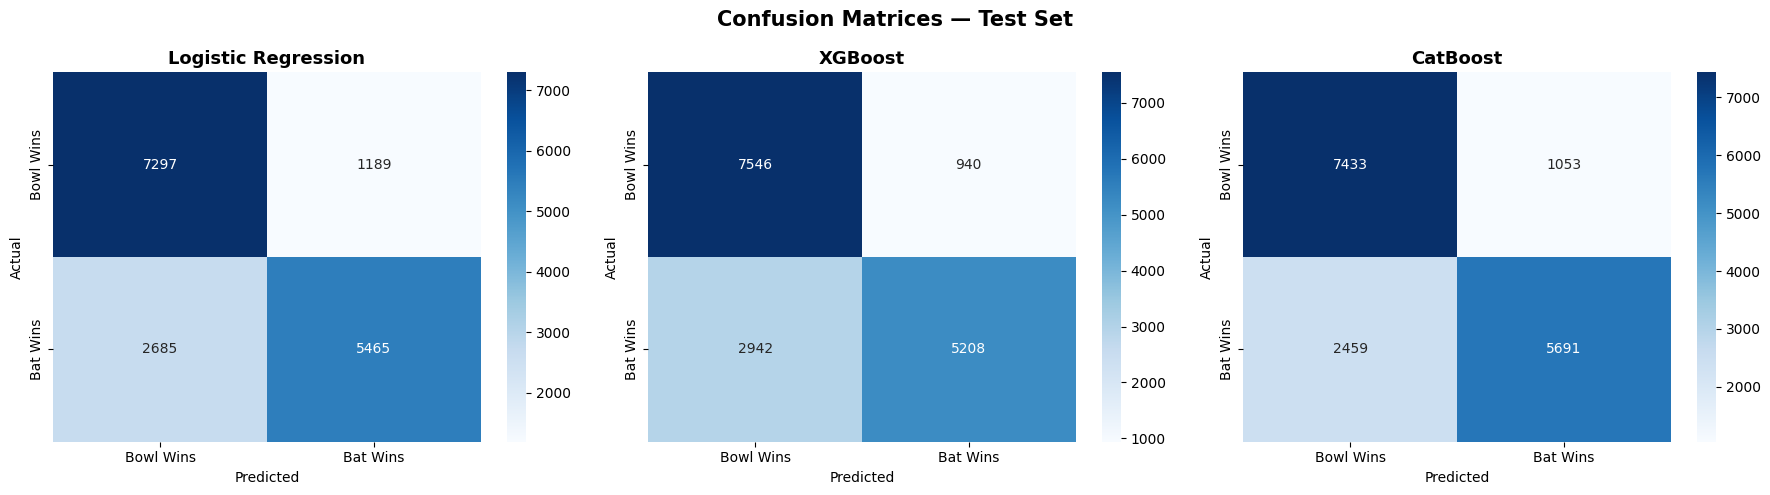

In [2549]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [lr_test_pred, xgb_test_pred, cat_test_pred],
    ['Logistic Regression', 'XGBoost', 'CatBoost']
):
    sns.heatmap(confusion_matrix(y_test, preds),
                annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bowl Wins', 'Bat Wins'],
                yticklabels=['Bowl Wins', 'Bat Wins'])

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

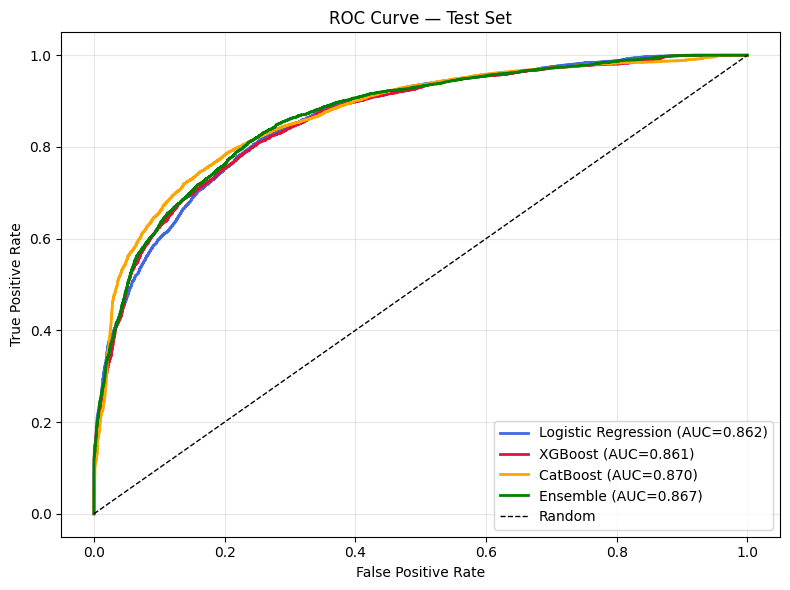

In [2550]:
fig, ax = plt.subplots(figsize=(8, 6))

for probs, name, color in [
    (lr_test_prob,  'Logistic Regression', 'royalblue'),
    (xgb_test_prob, 'XGBoost',             'crimson'),
    (cat_test_prob, 'CatBoost',            'orange'),
    (ens_test_prob, 'Ensemble',            'green'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr,
            label=f'{name} (AUC={roc_auc_score(y_test, probs):.3f})',
            color=color, lw=2)

ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set(xlabel='False Positive Rate',
       ylabel='True Positive Rate',
       title='ROC Curve — Test Set')

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

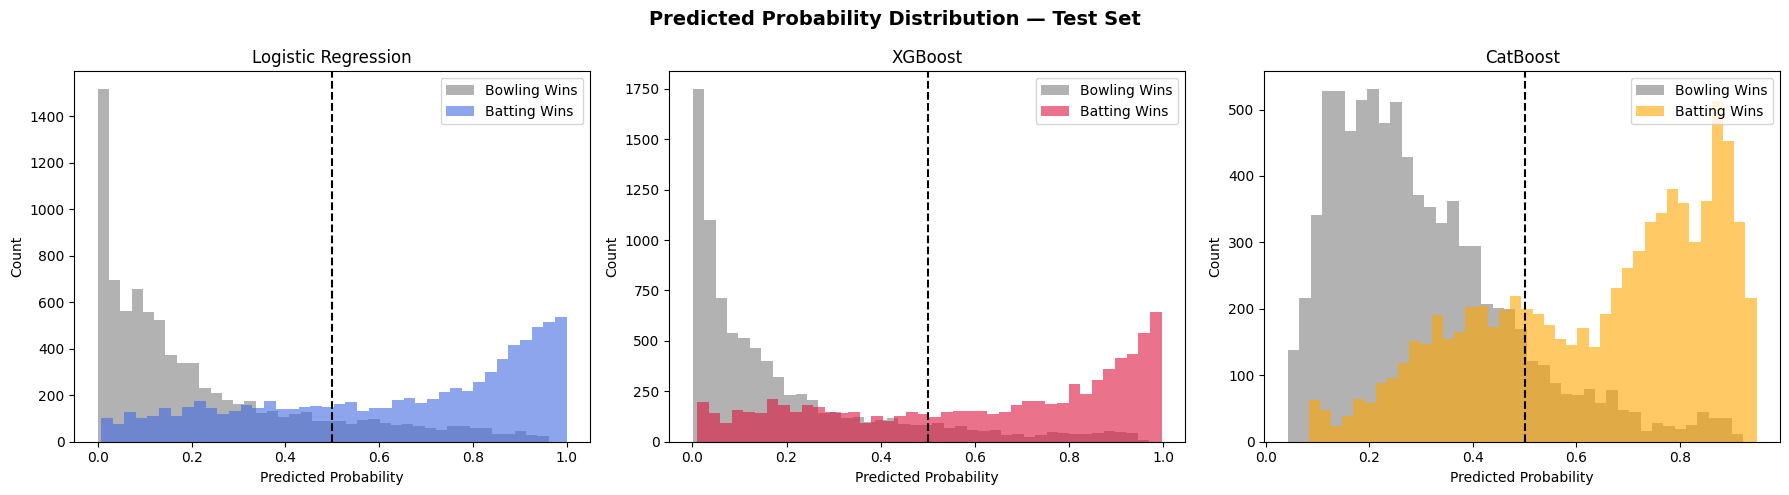

In [2551]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Predicted Probability Distribution — Test Set', fontsize=14, fontweight='bold')

for ax, probs, title, color in zip(
    axes,
    [lr_test_prob, xgb_test_prob, cat_test_prob],
    ['Logistic Regression', 'XGBoost', 'CatBoost'],
    ['royalblue', 'crimson', 'orange']
):
    ax.hist(probs[y_test==0], bins=40, alpha=0.6,
            label='Bowling Wins', color='gray')

    ax.hist(probs[y_test==1], bins=40, alpha=0.6,
            label='Batting Wins', color=color)

    ax.axvline(0.5, color='black', linestyle='--', lw=1.5)

    ax.set(title=title,
           xlabel='Predicted Probability',
           ylabel='Count')

    ax.legend()

plt.tight_layout()
plt.show()

In [2565]:
def predict_winner_all_models(
    batting_team, bowling_team, venue,
    runs_to_win, balls_remaining, wickets_remaining,
    team_runs_so_far, match_phase,
    first_innings_total,
    batting_team_perf=0.5, bowling_team_perf=0.5,
    batting_average=32.0, career_strike_rate=138.0,
    exp_bowler_eco=7.8, exp_bowler_avg=28.0,
    recent_runs=22, recent_wickets=1
):

    balls_bowled = 120 - balls_remaining
    curr_run_rate = (team_runs_so_far * 6) / balls_bowled if balls_bowled > 0 else 0
    req_run_rate  = (runs_to_win * 6) / balls_remaining
    crr_rrr_ratio = curr_run_rate / req_run_rate if req_run_rate > 0 else 0
    row = pd.DataFrame([{
        'batting_team':       batting_team,
        'bowling_team':       bowling_team,
        'venue':              venue,
        'runs_to_win':        runs_to_win,
        'curr_run_rate':      round(curr_run_rate, 2),
        'req_run_rate':       round(req_run_rate, 2),
        'crr_rrr_ratio':      round(crr_rrr_ratio, 4),
        'balls_remaining':    balls_remaining,
        'wickets_remaining':  wickets_remaining,
        'pressure':           round(req_run_rate - curr_run_rate, 2),
        'first_innings_total':first_innings_total,
        'match_phase':        match_phase,
        'batting_team_perf':  batting_team_perf,
        'bowling_team_perf':  bowling_team_perf,
        'batting_average':    batting_average,
        'career_strike_rate': career_strike_rate,
        'exp_bowler_eco':     exp_bowler_eco,
        'exp_bowler_avg':     exp_bowler_avg,
        'recent_runs':        recent_runs,
        'recent_wickets':     recent_wickets,
    }])


    lr_prob = pipe.predict_proba(row)[0]


    xgb_prob = xgb_pipe.predict_proba(row)[0]

    row_cb = row.copy()
    for col in ['batting_team', 'bowling_team', 'venue']:
        row_cb[col] = row_cb[col].astype(str)

    cat_prob = cat_model.predict_proba(row_cb)[0]

    ens_prob = 0.4 * xgb_prob + 0.4 * cat_prob + 0.2 * lr_prob

    print("\n" + "="*50)
    print(" WIN PROBABILITY COMPARISON")
    print("="*50)

    def print_model(name, prob):
        winner = batting_team if prob[1] >= 0.5 else bowling_team
        print(f"\n > {name}")
        print(f"  {batting_team} win prob : {prob[1]:.1%}")
        print(f"  {bowling_team} win prob : {prob[0]:.1%}")
        print(f"  Predicted winner → {winner}")

    print_model("Logistic Regression", lr_prob)
    print_model("XGBoost", xgb_prob)
    print_model("CatBoost", cat_prob)
    print_model("Ensemble (Best)\n", ens_prob)

    return {
        "lr": lr_prob,
        "xgb": xgb_prob,
        "cat": cat_prob,
        "ensemble": ens_prob
    }

In [2569]:
# predict_winner_all_models(
#     'GT', 'RR', 'narendra_modi_stadium',
#     runs_to_win=105, balls_remaining=59,
#     wickets_remaining=9, team_runs_so_far=82,
#     match_phase=1, first_innings_total=186
# )
predict_winner_all_models(
    'CSK', 'RCB', 'm_chinnaswamy_stadium',
    runs_to_win=146,
    balls_remaining=66,
    wickets_remaining=5,
    team_runs_so_far=105,
    match_phase=2,
    first_innings_total=251
)


 WIN PROBABILITY COMPARISON

 > Logistic Regression
  CSK win prob : 7.8%
  RCB win prob : 92.2%
  Predicted winner → RCB

 > XGBoost
  CSK win prob : 1.6%
  RCB win prob : 98.4%
  Predicted winner → RCB

 > CatBoost
  CSK win prob : 27.6%
  RCB win prob : 72.4%
  Predicted winner → RCB

 > Ensemble (Best)

  CSK win prob : 13.2%
  RCB win prob : 86.8%
  Predicted winner → RCB


{'lr': array([0.92214901, 0.07785099]),
 'xgb': array([0.9836242, 0.0163758], dtype=float32),
 'cat': array([0.72447633, 0.27552367]),
 'ensemble': array([0.86767003, 0.13232999])}

In [2553]:

'''
row = pd.DataFrame([{
    'batting_team': 'GT',
    'bowling_team': 'RR',
    'runs_to_win': 105,
    'curr_run_rate': round(82 / (61/6), 2),   # 8.07
    'req_run_rate': round(105 / (59/6), 2),    # 10.68
    'crr_rrr_ratio': round((82 / (61/6)) / (105 / (59/6)), 2),  # 0.76,
    'balls_remaining': 59,
    'wickets_remaining':9 , #ONLY 1 OUT
    # 'batting_average': 28,
    # 'career_strike_rate': 140,
    # 'exp_bowler_eco': 7.2,
    # 'exp_bowler_avg': 26,
    'pressure':  round((105 / (59/6)) / (82 / (61/6)), 2),
    'first_innings_total':186,
    "match_phase":1,
    "venue":"narendra_modi_stadium"
}])


[0]
[[0.6575856 0.3424144]]
RR will win the match


row = pd.DataFrame([{
    'batting_team': 'GT',
    'bowling_team': 'RR',
    'runs_to_win': 78,
    'curr_run_rate': round(100 / (79/6), 2),      # 7.59
    'req_run_rate': round(78 / (41/6), 2),         # 11.41
    'crr_rrr_ratio': round((100/(79/6)) / (78/(41/6)), 2),  # 0.67
    'balls_remaining': 41,
    'wickets_remaining': 5,
    'pressure': round((78/(41/6)) / (100/(79/6)), 2),  # 1.50
    'first_innings_total': 177,
    'match_phase': 1,   # over 13 → middle (5-14)
    "venue": "narendra_modi_stadium"
}])

pred_lr = pipe.predict(row)
pred_lr_proba=pipe.predict_proba(row)
print(pred_lr)
print(pred_lr_proba)
if pred_lr == 1:
  print(row['batting_team'].values[0], "will win the match")
else:
  print(row['bowling_team'].values[0], 'will win the match')


[0]
[[0.83415954 0.16584046]]
RR will win the match

row = pd.DataFrame([{
    'batting_team': 'GT',
    'bowling_team': 'RR',
    'runs_to_win': 34,
    'curr_run_rate': round(144 / (99/6), 2),            # 8.73
    'req_run_rate': round(34 / (21/6), 2),               # 9.71
    'crr_rrr_ratio': round((144/(99/6)) / (34/(21/6)), 2),   # 0.90
    'balls_remaining': 21,
    'wickets_remaining': 7,
    'pressure': round((34/(21/6)) / (144/(99/6)), 2),    # 1.11
    'first_innings_total': 177,
    'match_phase': 2,   # over 16 → death
    "venue": "narendra_modi_stadium"
}])

pred_lr = pipe.predict(row)
pred_lr_proba=pipe.predict_proba(row)
print(pred_lr)
print(pred_lr_proba)
if pred_lr == 1:
  print(row['batting_team'].values[0], "will win the match")
else:
  print(row['bowling_team'].values[0], 'will win the match')


[0]
[[0.58845044 0.41154956]]
RR will win the match

'''

'\nrow = pd.DataFrame([{\n    \'batting_team\': \'GT\',\n    \'bowling_team\': \'RR\',\n    \'runs_to_win\': 105,\n    \'curr_run_rate\': round(82 / (61/6), 2),   # 8.07\n    \'req_run_rate\': round(105 / (59/6), 2),    # 10.68\n    \'crr_rrr_ratio\': round((82 / (61/6)) / (105 / (59/6)), 2),  # 0.76,\n    \'balls_remaining\': 59,\n    \'wickets_remaining\':9 , #ONLY 1 OUT\n    # \'batting_average\': 28,\n    # \'career_strike_rate\': 140,\n    # \'exp_bowler_eco\': 7.2,\n    # \'exp_bowler_avg\': 26,\n    \'pressure\':  round((105 / (59/6)) / (82 / (61/6)), 2),\n    \'first_innings_total\':186,\n    "match_phase":1,\n    "venue":"narendra_modi_stadium"\n}])\n\n\n[0]\n[[0.6575856 0.3424144]]\nRR will win the match\n\n\nrow = pd.DataFrame([{\n    \'batting_team\': \'GT\',\n    \'bowling_team\': \'RR\',\n    \'runs_to_win\': 78,\n    \'curr_run_rate\': round(100 / (79/6), 2),      # 7.59\n    \'req_run_rate\': round(78 / (41/6), 2),         # 11.41\n    \'crr_rrr_ratio\': round((100/(79/